In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [7]:
import os
import gc
import math
import json
import random
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import densenet121, DenseNet121_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

from tqdm.auto import tqdm

In [3]:
SEED = 42

IMG_SIZE = 224
BATCH_SIZE = 32          # reduce to 16 if OOM
EPOCHS = 8               # first real run
LR = 5e-5
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_DIR = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
CSV_PATH = f"{BASE_DIR}/Data_Entry_2017.csv"
TRAIN_LIST_PATH = f"{BASE_DIR}/train_val_list.txt"
TEST_LIST_PATH = f"{BASE_DIR}/test_list.txt"
BBOX_PATH = f"{BASE_DIR}/BBox_List_2017.csv"

CHECKPOINT_PATH = "/kaggle/working/best_radtriage_model_full.pt"
METRICS_PATH = "/kaggle/working/test_metrics_full.csv"
PREDICTIONS_PATH = "/kaggle/working/test_predictions_full.csv"
WORKLIST_PATH = "/kaggle/working/worklist_simulation_full.csv"
THRESHOLDS_PATH = "/kaggle/working/best_thresholds_full.json"

CLASSES = [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Pleural_Thickening",
    "Hernia",
]

print("DEVICE:", DEVICE)

DEVICE: cuda


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [5]:
all_pngs = glob(f"{BASE_DIR}/images_*/images/*.png")
print("Total PNG files found:", len(all_pngs))

image_path_map = {os.path.basename(p): p for p in all_pngs}
print("Unique mapped filenames:", len(image_path_map))

Total PNG files found: 112120
Unique mapped filenames: 112120


In [6]:
df = pd.read_csv(CSV_PATH)
print("Metadata shape:", df.shape)
print(df.columns.tolist())
df.head()

Metadata shape: (112120, 12)
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [7]:
df["image_path"] = df["Image Index"].map(image_path_map)

missing_paths = df["image_path"].isna().sum()
print("Missing image paths:", missing_paths)

df = df.dropna(subset=["image_path"]).reset_index(drop=True)
print("Rows after mapping image paths:", len(df))

Missing image paths: 0
Rows after mapping image paths: 112120


In [8]:
def encode_labels(label_str, class_names):
    labels = [x.strip() for x in str(label_str).split("|")]
    target = np.zeros(len(class_names), dtype=np.float32)
    for i, cls in enumerate(class_names):
        if cls in labels:
            target[i] = 1.0
    return target

df["target"] = df["Finding Labels"].apply(lambda x: encode_labels(x, CLASSES))

In [9]:
all_labels = set()
for s in df["Finding Labels"].astype(str):
    for label in s.split("|"):
        all_labels.add(label.strip())

print(sorted(all_labels))

['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [10]:
targets_full = np.stack(df["target"].values)

label_dist_df = pd.DataFrame({
    "class": CLASSES,
    "positive_count": targets_full.sum(axis=0).astype(int),
    "prevalence": targets_full.sum(axis=0) / len(df)
}).sort_values("positive_count", ascending=False)

label_dist_df

,class,positive_count,prevalence
3,Infiltration,19894,0.177435
2,Effusion,13317,0.118775
0,Atelectasis,11559,0.103095
5,Nodule,6331,0.056466
4,Mass,5782,0.051570
7,Pneumothorax,5302,0.047289
8,Consolidation,4667,0.041625
12,Pleural_Thickening,3385,0.030191
1,Cardiomegaly,2776,0.024759
10,Emphysema,2516,0.022440


In [11]:
with open(TRAIN_LIST_PATH, "r") as f:
    train_val_names = [line.strip() for line in f if line.strip()]

with open(TEST_LIST_PATH, "r") as f:
    test_names = [line.strip() for line in f if line.strip()]

print("Train/Val names:", len(train_val_names))
print("Test names:", len(test_names))

Train/Val names: 86524
Test names: 25596


In [12]:
train_val_df = df[df["Image Index"].isin(train_val_names)].reset_index(drop=True)
test_df = df[df["Image Index"].isin(test_names)].reset_index(drop=True)

print("train_val_df:", len(train_val_df))
print("test_df:", len(test_df))

train_val_df: 86524
test_df: 25596


In [13]:
unique_train_val_patients = train_val_df["Patient ID"].unique()

train_patients, val_patients = train_test_split(
    unique_train_val_patients,
    test_size=0.12,
    random_state=SEED
)

train_df = train_val_df[train_val_df["Patient ID"].isin(train_patients)].reset_index(drop=True)
val_df = train_val_df[train_val_df["Patient ID"].isin(val_patients)].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 76277
Val: 10247
Test: 25596


In [14]:
assert set(train_df["Patient ID"]).isdisjoint(set(val_df["Patient ID"]))
assert set(train_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
assert set(val_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))

print("No patient leakage across train/val/test.")

No patient leakage across train/val/test.


In [15]:
USE_SMOKE_TEST = False

if USE_SMOKE_TEST:
    train_df_use = train_df.sample(8000, random_state=SEED).reset_index(drop=True)
    val_df_use = val_df.sample(1500, random_state=SEED).reset_index(drop=True)
    test_df_use = test_df.sample(1500, random_state=SEED).reset_index(drop=True)
    epochs_to_run = 2
else:
    train_df_use = train_df
    val_df_use = val_df
    test_df_use = test_df
    epochs_to_run = EPOCHS

print("Train used:", len(train_df_use))
print("Val used:", len(val_df_use))
print("Test used:", len(test_df_use))
print("Epochs:", epochs_to_run)

Train used: 76277
Val used: 10247
Test used: 25596
Epochs: 8


In [16]:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [17]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("L")
        image = Image.merge("RGB", (image, image, image))

        if self.transform:
            image = self.transform(image)

        target = torch.tensor(row["target"], dtype=torch.float32)

        return {
            "image": image,
            "target": target,
            "image_id": row["Image Index"],
            "patient_id": row["Patient ID"],
            "image_path": row["image_path"]
        }

In [18]:
train_targets = np.stack(train_df_use["target"].values)

pos_counts = train_targets.sum(axis=0)
neg_counts = len(train_targets) - pos_counts
pos_weight = neg_counts / (pos_counts + 1e-6)

class_weight_df = pd.DataFrame({
    "class": CLASSES,
    "pos_count": pos_counts.astype(int),
    "neg_count": neg_counts.astype(int),
    "pos_weight": pos_weight
}).sort_values("pos_count")

class_weight_df

,class,pos_count,neg_count,pos_weight
13,Hernia,115,76162,662.278259
6,Pneumonia,765,75512,98.708496
11,Fibrosis,1084,75193,69.366234
9,Edema,1234,75043,60.812805
10,Emphysema,1295,74982,57.901157
1,Cardiomegaly,1509,74768,49.548046
12,Pleural_Thickening,1931,74346,38.501293
7,Pneumothorax,2337,73940,31.638853
8,Consolidation,2542,73735,29.006687
4,Mass,3554,72723,20.462296


In [19]:
sample_weights = []
for target in train_targets:
    positive_indices = np.where(target == 1)[0]
    if len(positive_indices) > 0:
        weight = float(np.max(pos_weight[positive_indices]))
    else:
        weight = 1.0
    sample_weights.append(weight)

sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [20]:
train_ds = ChestXrayDataset(train_df_use, transform=train_transform)
val_ds = ChestXrayDataset(val_df_use, transform=eval_transform)
test_ds = ChestXrayDataset(test_df_use, transform=eval_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 2384
Val batches: 321
Test batches: 800


In [21]:
batch = next(iter(train_loader))
print(batch["image"].shape)
print(batch["target"].shape)
print(batch["image_id"][:3])

torch.Size([32, 3, 224, 224])
torch.Size([32, 14])
['00001524_000.png', '00003186_004.png', '00001301_010.png']


In [22]:
class RadTriageDenseNet(nn.Module):
    def __init__(self, num_classes=14, pretrained=True, dropout=0.3):
        super().__init__()
        weights = DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = densenet121(weights=weights)
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = RadTriageDenseNet(num_classes=len(CLASSES), pretrained=True, dropout=0.3).to(DEVICE)
model

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 162MB/s]


RadTriageDenseNet(
  (backbone): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, m

In [23]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight, dtype=torch.float32).to(DEVICE)
)

optimizer = optim.AdamW([
    {"params": model.backbone.features.parameters(), "lr": 1e-5},
    {"params": model.backbone.classifier.parameters(), "lr": 5e-5},
], weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [24]:
def compute_multilabel_metrics(y_true, y_prob, thresholds=None):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    if thresholds is None:
        thresholds = np.array([0.5] * y_true.shape[1])

    y_pred = (y_prob >= thresholds).astype(int)

    per_class_auc = {}
    per_class_f1 = {}
    sensitivities = {}
    specificities = {}

    for i, cls in enumerate(CLASSES):
        try:
            auc = roc_auc_score(y_true[:, i], y_prob[:, i])
        except Exception:
            auc = np.nan

        per_class_auc[cls] = auc
        per_class_f1[cls] = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)

        cm = confusion_matrix(y_true[:, i], y_pred[:, i], labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        sensitivities[cls] = tp / (tp + fn + 1e-6)
        specificities[cls] = tn / (tn + fp + 1e-6)

    macro_auc = np.nanmean(list(per_class_auc.values()))
    macro_f1 = np.mean(list(per_class_f1.values()))

    return {
        "macro_auc": macro_auc,
        "macro_f1": macro_f1,
        "per_class_auc": per_class_auc,
        "per_class_f1": per_class_f1,
        "sensitivities": sensitivities,
        "specificities": specificities
    }

In [25]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    running_loss = 0.0

    for batch in tqdm(loader, leave=False):
        images = batch["image"].to(device)
        targets = batch["target"].to(device)

        optimizer.zero_grad()

        with autocast():
            logits = model(images)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)

/tmp/ipykernel_55/2848699388.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [26]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            images = batch["image"].to(device)
            targets = batch["target"].to(device)

            logits = model(images)
            loss = criterion(logits, targets)

            probs = torch.sigmoid(logits)

            running_loss += loss.item() * images.size(0)
            all_targets.append(targets.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    val_loss = running_loss / len(loader.dataset)
    all_targets = np.concatenate(all_targets, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)

    metrics = compute_multilabel_metrics(all_targets, all_probs)

    return val_loss, metrics, all_targets, all_probs

In [27]:
best_auc = -np.inf
patience = 2
patience_counter = 0
history = []

for epoch in range(epochs_to_run):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, scaler)
    val_loss, val_metrics, val_targets, val_probs = validate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_metrics["macro_auc"])

    print(f"Epoch {epoch+1}/{epochs_to_run}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val Macro AUC: {val_metrics['macro_auc']:.4f}")
    print(f"Val Macro F1:  {val_metrics['macro_f1']:.4f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_macro_auc": val_metrics["macro_auc"],
        "val_macro_f1": val_metrics["macro_f1"]
    })

    if val_metrics["macro_auc"] > best_auc:
        best_auc = val_metrics["macro_auc"]
        patience_counter = 0
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_auc": best_auc,
            "classes": CLASSES
        }, CHECKPOINT_PATH)
        print("Saved best model.")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

  0%|          | 0/2384 [00:00<?, ?it/s]

/tmp/ipykernel_55/2848699388.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  0%|          | 0/321 [00:00<?, ?it/s]

Epoch 1/8
Train Loss: 2.2400
Val Loss:   1.5068
Val Macro AUC: 0.7348
Val Macro F1:  0.0940
Saved best model.


  0%|          | 0/2384 [00:00<?, ?it/s]

...

Epoch 7/8
Train Loss: 1.2019
Val Loss:   1.4532
Val Macro AUC: 0.7706
Val Macro F1:  0.1282


  0%|          | 0/2384 [00:00<?, ?it/s]

/tmp/ipykernel_55/2848699388.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  0%|          | 0/321 [00:00<?, ?it/s]

Epoch 8/8
Train Loss: 1.1380
Val Loss:   1.4697
Val Macro AUC: 0.7713
Val Macro F1:  0.1339
Early stopping triggered.


In [4]:
history_df = pd.DataFrame(history)
history_df

NameError: name 'pd' is not defined

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["val_macro_auc"], label="val_macro_auc")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.show()

NameError: name 'plt' is not defined

In [6]:
# model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
# model.eval()
# print("Loaded best checkpoint from:", CHECKPOINT_PATH)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded best checkpoint from:", CHECKPOINT_PATH)
print("Best val AUC:", checkpoint["best_auc"])
print("Saved epoch:", checkpoint["epoch"])

NameError: name 'torch' is not defined

In [3]:
_, _, val_targets, val_probs = validate(model, val_loader, criterion, DEVICE)
best_thresholds = []

for i, cls in enumerate(CLASSES):
    positives = val_targets[:, i].sum()

    # adaptive search range
    if positives < 200:
        search_range = np.arange(0.2, 0.75, 0.05)
    else:
        search_range = np.arange(0.3, 0.9, 0.05)

    best_thr = 0.5
    best_f1 = -1

    for thr in search_range:
        preds = (val_probs[:, i] >= thr).astype(int)

        # compute precision & recall manually
        tp = ((preds == 1) & (val_targets[:, i] == 1)).sum()
        fp = ((preds == 1) & (val_targets[:, i] == 0)).sum()
        fn = ((preds == 0) & (val_targets[:, i] == 1)).sum()

        precision = tp / (tp + fp + 1e-6)
        recall = tp / (tp + fn + 1e-6)

        # 🔥 enforce balance
        if precision < 0.2:
            continue

        f1 = 2 * precision * recall / (precision + recall + 1e-6)

        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    best_thresholds.append(float(best_thr))

best_thresholds = np.array(best_thresholds)

NameError: name 'CLASSES' is not defined

In [53]:
threshold_dict = {cls: float(thr) for cls, thr in zip(CLASSES, best_thresholds)}

with open(THRESHOLDS_PATH, "w") as f:
    json.dump(threshold_dict, f, indent=2)

threshold_dict

{'Atelectasis': 0.7999999999999998,
 'Cardiomegaly': 0.55,
 'Effusion': 0.7999999999999998,
 'Infiltration': 0.6499999999999999,
 'Mass': 0.8499999999999999,
 'Nodule': 0.8499999999999999,
 'Pneumonia': 0.55,
 'Pneumothorax': 0.8499999999999999,
 'Consolidation': 0.8499999999999999,
 'Edema': 0.55,
 'Emphysema': 0.55,
 'Fibrosis': 0.55,
 'Pleural_Thickening': 0.8499999999999999,
 'Hernia': 0.55}

In [54]:
test_loss, test_metrics, test_targets, test_probs = validate(model, test_loader, criterion, DEVICE)
test_metrics_tuned = compute_multilabel_metrics(test_targets, test_probs, thresholds=best_thresholds)

print("Test Loss:", test_loss)
print("Test Macro AUC:", test_metrics_tuned["macro_auc"])
print("Test Macro F1:", test_metrics_tuned["macro_f1"])

  0%|          | 0/800 [00:00<?, ?it/s]

Test Loss: 1.6847321449415555
Test Macro AUC: 0.7687565505529749
Test Macro F1: 0.242749900991703


In [55]:
metrics_df = pd.DataFrame({
    "class": CLASSES,
    "auc": [test_metrics_tuned["per_class_auc"][c] for c in CLASSES],
    "f1": [test_metrics_tuned["per_class_f1"][c] for c in CLASSES],
    "sensitivity": [test_metrics_tuned["sensitivities"][c] for c in CLASSES],
    "specificity": [test_metrics_tuned["specificities"][c] for c in CLASSES],
    "threshold": [threshold_dict[c] for c in CLASSES]
})

metrics_df = metrics_df.sort_values("auc", ascending=False).reset_index(drop=True)
metrics_df

,class,auc,f1,sensitivity,specificity,threshold
0,Hernia,0.917674,0.178253,0.581395,0.983340,0.55
1,Emphysema,0.871557,0.195558,0.870082,0.686487,0.55
2,Cardiomegaly,0.843496,0.194535,0.785781,0.725731,0.55
3,Pneumothorax,0.835099,0.437994,0.665291,0.840478,0.85
4,Edema,0.828382,0.126819,0.932973,0.520814,0.55
5,Effusion,0.785529,0.475512,0.608630,0.788375,0.80
6,Fibrosis,0.780607,0.063797,0.802299,0.596320,0.55
7,Mass,0.735716,0.275315,0.437071,0.872610,0.85
8,Pleural_Thickening,0.725358,0.166927,0.560805,0.758884,0.85
9,Atelectasis,0.723870,0.333107,0.374199,0.871802,0.80


In [56]:
metrics_df.to_csv(METRICS_PATH, index=False)
print("Saved metrics to:", METRICS_PATH)

Saved metrics to: /kaggle/working/test_metrics_full.csv


In [57]:
pred_df = test_df_use[["Image Index", "Patient ID", "Finding Labels", "image_path"]].copy().reset_index(drop=True)

for i, cls in enumerate(CLASSES):
    pred_df[f"true_{cls}"] = test_targets[:, i].astype(int)
    pred_df[f"prob_{cls}"] = test_probs[:, i]

pred_df.to_csv(PREDICTIONS_PATH, index=False)
print("Saved predictions to:", PREDICTIONS_PATH)
pred_df.head()

Saved predictions to: /kaggle/working/test_predictions_full.csv


,Image Index,Patient ID,Finding Labels,image_path,true_Atelectasis,prob_Atelectasis,true_Cardiomegaly,prob_Cardiomegaly,true_Effusion,prob_Effusion,...,true_Edema,prob_Edema,true_Emphysema,prob_Emphysema,true_Fibrosis,prob_Fibrosis,true_Pleural_Thickening,prob_Pleural_Thickening,true_Hernia,prob_Hernia
0,00000003_000.png,3,Hernia,/kaggle/input/datasets/organizations/nih-chest...,0,0.447102,0,0.010309,0,0.277475,...,0,0.056448,0,0.222374,0,0.370031,0,0.405072,1,0.998931
1,00000003_001.png,3,Hernia,/kaggle/input/datasets/organizations/nih-chest...,0,0.745534,0,0.090346,0,0.422060,...,0,0.138002,0,0.292981,0,0.977833,0,0.815920,1,0.886261
2,00000003_002.png,3,Hernia,/kaggle/input/datasets/organizations/nih-chest...,0,0.472852,0,0.294676,0,0.674237,...,0,0.032782,0,0.244869,0,0.111199,0,0.574849,1,0.999990
3,00000003_003.png,3,Hernia|Infiltration,/kaggle/input/datasets/organizations/nih-chest...,0,0.587255,0,0.045840,0,0.357989,...,0,0.121892,0,0.350041,0,0.759252,0,0.654443,1,0.999716
4,00000003_004.png,3,Hernia,/kaggle/input/datasets/organizations/nih-chest...,0,0.754963,0,0.020562,0,0.463517,...,0,0.049407,0,0.113419,0,0.456009,0,0.257033,1,0.999957


In [58]:
def preprocess_single_image(image_path):
    image = Image.open(image_path).convert("L")
    rgb = Image.merge("RGB", (image, image, image))
    tensor = eval_transform(rgb).unsqueeze(0).to(DEVICE)
    return image, rgb, tensor

In [60]:
def predict_single_image(model, image_path, thresholds=None):
    model.eval()
    gray_img, rgb_img, tensor = preprocess_single_image(image_path)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    if thresholds is None:
        thresholds = np.array([0.5] * len(CLASSES))

    pred_binary = (probs >= thresholds).astype(int)

    result_df = pd.DataFrame({
        "class": CLASSES,
        "probability": probs,
        "predicted": pred_binary
    }).sort_values("probability", ascending=False).reset_index(drop=True)

    return gray_img, rgb_img, tensor, probs, result_df

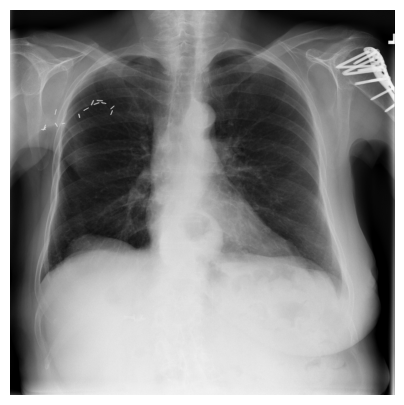

,class,probability,predicted
0,Hernia,0.998931,1
1,Mass,0.562910,0
2,Atelectasis,0.447102,0
3,Pleural_Thickening,0.405072,0
4,Fibrosis,0.370030,0
5,Nodule,0.352597,0
6,Infiltration,0.308550,0
7,Effusion,0.277475,0
8,Emphysema,0.222374,0
9,Consolidation,0.203396,0


In [61]:
sample_path = test_df_use.iloc[0]["image_path"]

gray_img, rgb_img, tensor, probs, result_df = predict_single_image(
    model, sample_path, best_thresholds
)

plt.figure(figsize=(5, 5))
plt.imshow(gray_img, cmap="gray")
plt.axis("off")
plt.show()

result_df.head(10)

In [63]:
SEVERITY_WEIGHTS = {
    "Atelectasis": 0.35,
    "Cardiomegaly": 0.45,
    "Effusion": 0.55,
    "Infiltration": 0.50,
    "Mass": 0.60,
    "Nodule": 0.30,
    "Pneumonia": 0.75,
    "Pneumothorax": 1.00,
    "Consolidation": 0.65,
    "Edema": 0.80,
    "Emphysema": 0.30,
    "Fibrosis": 0.25,
    "Pleural_Thickening": 0.20,
    "Hernia": 0.15,
}

In [64]:
def compute_triage_score(probs):
    score = 0.0
    for i, cls in enumerate(CLASSES):
        score += probs[i] * SEVERITY_WEIGHTS[cls]
    return float(score)

def assign_triage_tier(probs, score):
    prob_map = {cls: probs[i] for i, cls in enumerate(CLASSES)}

    if prob_map["Pneumothorax"] >= 0.60:
        return "Emergent"
    elif prob_map["Edema"] >= 0.70 or prob_map["Pneumonia"] >= 0.70:
        return "Urgent"
    elif score >= 0.75:
        return "Emergent"
    elif score >= 0.40:
        return "Urgent"
    else:
        return "Routine"

In [65]:
score = compute_triage_score(probs)
tier = assign_triage_tier(probs, score)

print("Urgency Score:", score)
print("Triage Tier:", tier)

Urgency Score: 1.6357648372650146
Triage Tier: Emergent


In [66]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.fwd_hook = self.target_layer.register_forward_hook(self.save_activation)
        self.bwd_hook = self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inp, out):
        self.activations = out

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx):
        self.model.eval()
        self.model.zero_grad()

        logits = self.model(input_tensor)
        target = logits[:, class_idx]
        target.backward()

        grads = self.gradients[0]
        acts = self.activations[0]

        weights = grads.mean(dim=(1, 2))
        cam = torch.zeros(acts.shape[1:], dtype=torch.float32, device=acts.device)

        for i, w in enumerate(weights):
            cam += w * acts[i]

        cam = torch.relu(cam)
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.detach().cpu().numpy()

    def close(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()

In [67]:
def overlay_cam_on_image(gray_image, cam, alpha=0.4):
    gray_np = np.array(gray_image)
    cam_img = Image.fromarray(np.uint8(cam * 255)).resize(gray_image.size)
    cam_np = np.array(cam_img) / 255.0

    plt.figure(figsize=(6, 6))
    plt.imshow(gray_np, cmap="gray")
    plt.imshow(cam_np, cmap="jet", alpha=alpha)
    plt.axis("off")
    plt.show()

Top predicted class: Hernia


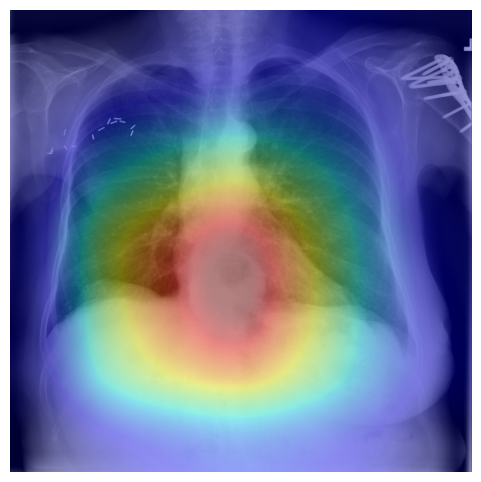

In [68]:
gradcam = GradCAM(model, model.backbone.features.denseblock4)

top_class_idx = int(np.argmax(probs))
print("Top predicted class:", CLASSES[top_class_idx])

cam = gradcam.generate(tensor, top_class_idx)
overlay_cam_on_image(gray_img, cam)

In [69]:
def run_case(model, image_path, thresholds):
    gray_img, rgb_img, tensor, probs, result_df = predict_single_image(model, image_path, thresholds)
    score = compute_triage_score(probs)
    tier = assign_triage_tier(probs, score)

    top_finding = result_df.iloc[0]["class"]
    top_prob = float(result_df.iloc[0]["probability"])

    return {
        "image_path": image_path,
        "top_finding": top_finding,
        "top_probability": top_prob,
        "urgency_score": score,
        "triage_tier": tier
    }

In [70]:
sample_cases = test_df_use.sample(10, random_state=SEED).reset_index(drop=True)

results = []
for i, row in sample_cases.iterrows():
    out = run_case(model, row["image_path"], best_thresholds)
    out["original_rank"] = i + 1
    out["image_id"] = row["Image Index"]
    results.append(out)

worklist_df = pd.DataFrame(results)
worklist_df = worklist_df.sort_values("urgency_score", ascending=False).reset_index(drop=True)
worklist_df["new_rank"] = np.arange(1, len(worklist_df) + 1)

worklist_df[[
    "image_id",
    "original_rank",
    "new_rank",
    "top_finding",
    "top_probability",
    "urgency_score",
    "triage_tier"
]]

,image_id,original_rank,new_rank,top_finding,top_probability,urgency_score,triage_tier
0,00014203_063.png,10,1,Edema,0.992921,4.234187,Urgent
1,00004188_003.png,7,2,Fibrosis,0.936090,4.022773,Urgent
2,00028518_011.png,4,3,Edema,0.963108,3.983034,Emergent
3,00013659_006.png,1,4,Mass,0.942551,3.700692,Emergent
4,00012094_061.png,9,5,Fibrosis,0.976656,3.651896,Emergent
5,00019018_026.png,3,6,Consolidation,0.782281,3.644876,Emergent
6,00027542_005.png,8,7,Emphysema,0.989764,3.330356,Emergent
7,00030445_000.png,2,8,Fibrosis,0.953227,3.158081,Emergent
8,00023026_000.png,5,9,Fibrosis,0.938400,3.032834,Emergent
9,00014125_004.png,6,10,Mass,0.919508,2.615218,Emergent


In [71]:
worklist_df.to_csv(WORKLIST_PATH, index=False)
print("Saved worklist simulation to:", WORKLIST_PATH)

Saved worklist simulation to: /kaggle/working/worklist_simulation_full.csv


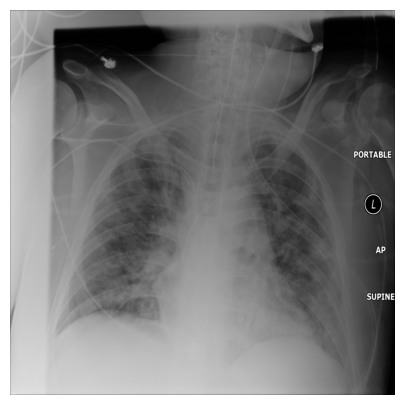

Top finding: Edema
Top probability: 0.9929211735725403
Urgency score: 4.23418664932251
Triage tier: Urgent


,class,probability,predicted
0,Edema,0.992921,1
1,Pneumonia,0.933951,1
2,Consolidation,0.806012,0
3,Infiltration,0.785113,1
4,Nodule,0.733723,0
5,Mass,0.628555,0
6,Effusion,0.574555,0
7,Cardiomegaly,0.533537,0
8,Atelectasis,0.496527,0
9,Pleural_Thickening,0.491590,0


In [72]:
top_case_path = worklist_df.iloc[0]["image_path"]
gray_img2, rgb_img2, tensor2, probs2, result_df2 = predict_single_image(model, top_case_path, best_thresholds)

plt.figure(figsize=(5, 5))
plt.imshow(gray_img2, cmap="gray")
plt.axis("off")
plt.show()

print("Top finding:", result_df2.iloc[0]["class"])
print("Top probability:", float(result_df2.iloc[0]["probability"]))
print("Urgency score:", compute_triage_score(probs2))
print("Triage tier:", assign_triage_tier(probs2, compute_triage_score(probs2)))

result_df2.head(10)

In [73]:
try:
    gradcam.close()
except:
    pass

gc.collect()
torch.cuda.empty_cache()
print("Cleanup done.")

Cleanup done.
